# Low Fidelity Neural Network
Neural Network which uses LF dataset and exploits the Low fidelity component of the MF model. The NN is tested also on the HF test set  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import load_model, save_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data Preparation

In [ ]:
# Linear constitutive law for the LF data
mu_train_LF = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/mu_train_LF.txt")
U_lf_train = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/Ulf_train.txt")
n_bases_train= U_lf_train.shape[1] 

In [ ]:
# import of the test data
# st.Venant constitutive law for the HF data

mu_test = np.loadtxt("../DATA_shear/Data_Test_bases/mu_test.txt")
mu_max = np.loadtxt("../DATA_shear/Data_Test_bases/mu_max.txt")
mu_min = np.loadtxt("../DATA_shear/Data_Test_bases/mu_min.txt")

# st.Venant constitutive law for the LF data
U_lf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Ulf_test.txt")
n_bases_test= U_lf_test.shape[1]

n_bases=min(n_bases_test,n_bases_train)

print(f"Nb. of considered bases is {n_bases}")
# I create a list of the models
model_list=[0]*n_bases

In [ ]:
U_hf_train = np.loadtxt("../DATA_shear/Data_Train_bases_short/Uhf_train.txt")
U_hf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Uhf_test.txt")

U_lf_train=U_lf_train-np.mean(U_hf_train)

U_lf_test=U_lf_test-np.mean(U_hf_test)
U_hf_test=U_hf_test-np.mean(U_hf_test)

mu_test=(mu_test-mu_min)/(mu_max-mu_min)
mu_train_LF=(mu_train_LF-mu_min)/(mu_max-mu_min)

In [ ]:
plt.subplot(1, 3, 1)
plt.scatter(mu_train_LF[:,0], U_lf_train, label='HF_data', color='blue', marker='o')
plt.xlabel('Y')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

plt.subplot(1, 3, 2)
plt.scatter(mu_train_LF[:,1], U_lf_train, label='HF_data', color='blue', marker='o')
plt.xlabel('P')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

plt.subplot(1, 3, 3)
plt.scatter(mu_train_LF[:,2], U_lf_train, label='HF_data', color='blue', marker='o')
plt.xlabel('F')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

In [ ]:
Nlf = 10
U_LF_list = []
NepoLF=3000

r2_LF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores HF R^2
mse_LF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores HF MSE

## Neural Network
Cycle on the Discretization and the value of the diffusion 

In [ ]:
# Name of the folder
folder_name = "LF_model"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

test_mse_HF_list = []

r2_HF_list = []

permutation = np.random.permutation(len(mu_train_LF))
mu_LF = mu_train_LF[permutation,:][0:Nlf,:]
U_LF = U_lf_train[permutation][0:Nlf]

In [4]:
name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 



LF Model:
The function training took 52.11686897277832 seconds.


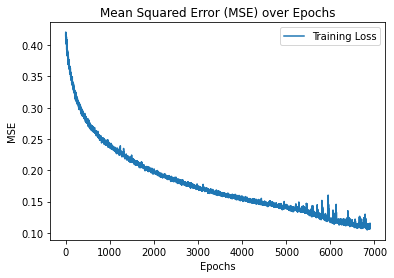

Test MSE: 0.04380531083007348
R^2: 0.6441277266573552


In [5]:
####################    NN training and PREDICTION    #######################

print("\nLF Model:")

model= NetworkFactory.build_network("LF",params=best_params,data_train=mu_train_LF,output_train=U_LF,N=NepoLF,n=Nlf,do_HPO=False,verbose=False)
ULF = model.prediction(mu_LF)

(mse_LF,R_LF) = model.performance(mu_test,U_lf_test)


## High Fidelity data

In [6]:

UHF = model.prediction(mu_test)
(mse_HF,R_HF) = model.performance(mu_test,U_hf_test)



Test MSE: 0.16572055268281788
R^2: -0.46397816692187077


# Plot

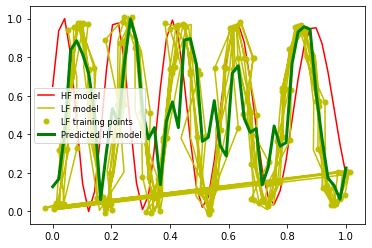

In [7]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model")
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_LF_test[:,0], U_LF_test, "y-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "yo",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_HF_test_original[:,0],
    model.prediction(reaction_HF_test_original),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

#########################     SAVE the OUTPUT      ##########################
os.makedirs("NNLF_LF200_7000_noise_fourier")

R2_HF = pandas.DataFrame({"R2_HF": [R_HF]})
R2_LF = pandas.DataFrame({"R2_LF": [R_LF]})
MSE_test_LF = pandas.DataFrame({"MSE_test_LF": [mse_LF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [mse_HF]})


R2_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_HF.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_LF.to_csv(
    "./NNLF_LF200_7000_noise_fourier/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
